# 🧠 LLM Distillation — Knowledge Transfer for Large Language Models

> **LLM Distillation** extends classical knowledge distillation (Hinton et al., 2015) to the scale of billion-parameter language models. A large, expensive **teacher** LLM transfers its "knowledge" to a smaller, faster **student** LLM — enabling deployment on resource-constrained hardware while preserving most of the teacher's capability.

---

## 🆚 LLM Distillation vs. Classical Distillation

| Dimension | Classical (e.g., MLP on MNIST) | LLM Distillation |
|---|---|---|
| Teacher size | Thousands–millions of params | Billions of params (GPT-4, Llama-3-70B) |
| Output space | Fixed-size class probabilities | Vocabulary-size token distributions (50k+) |
| Transfer signals | Logit soft targets only | Logits + hidden states + attention maps |
| Data | Labelled dataset | Synthetic data generated by teacher |
| Cost | Minutes | Days–weeks on GPU clusters |
| Real examples | — | DistilBERT, TinyBERT, Alpaca, Orca, Phi |

---

## 📋 Notebook Sections

| # | Section | Topics |
|---|---|---|
| 1 | **Imports & Setup** | Libraries, device config |
| 2 | **Taxonomy of LLM Distillation** | White-box, black-box, task-specific, open-ended |
| 3 | **Distillation Loss Functions** | Token KL, hidden-state MSE, attention transfer, intermediate layer matching |
| 4 | **From Scratch: Sequence-Level KD** | Token-level distillation on a causal LM with `transformers` |
| 5 | **Feature-Based Distillation (TinyBERT-style)** | Hidden state + attention alignment |
| 6 | **Black-Box Distillation (Data-Driven)** | Using teacher-generated data (Alpaca / Orca paradigm) |
| 7 | **DistilBERT Case Study** | Load & inspect the real distilled BERT model |
| 8 | **Evaluation** | Perplexity, downstream accuracy, compression metrics |
| 9 | **Benchmarks & Comparison** | Size, speed, quality across real distilled LLMs |
| 10 | **Best Practices & Decision Guide** | When to use which strategy |

---
## 1. Imports & Setup

We use:
- **`transformers`** — Load pre-trained teacher/student LLMs and tokenizers.
- **`torch`** — Core training loop, loss functions, gradient updates.
- **`datasets`** — Hugging Face dataset hub for training/evaluation corpora.
- **`numpy` / `matplotlib`** — Numerical operations and visualisation.

In [ ]:
# Uncomment once to install required packages
# !pip install -q transformers datasets accelerate sentencepiece evaluate

In [1]:
# ── Standard libraries ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import time
import math
warnings.filterwarnings('ignore')

# ── PyTorch ────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ── Hugging Face ───────────────────────────────────────────────────────────────
from transformers import (
    AutoModelForCausalLM,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    GPT2LMHeadModel,
    GPT2Tokenizer,
    DistilBertModel,
    DistilBertTokenizer,
    BertModel,
    BertTokenizer,
    DataCollatorForLanguageModeling,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

print(f"Device          : {DEVICE}")
print(f"PyTorch version : {torch.__version__}")
if DEVICE == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device          : cuda
PyTorch version : 2.8.0+cu128
GPU             : NVIDIA H100 80GB HBM3
VRAM            : 85.0 GB


---
## 2. Taxonomy of LLM Distillation Strategies

LLM distillation methods fall along two key axes:

### Axis 1: Access to Teacher Internals

```
WHITE-BOX DISTILLATION                    BLACK-BOX DISTILLATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━         ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Full access to teacher weights,           Only teacher outputs (text/logits)
logits, hidden states, gradients.         are available — via API or file.

Examples:                                 Examples:
  • DistilBERT (Sanh et al. 2019)           • Alpaca (Stanford, 2023)
  • TinyBERT (Jiao et al. 2020)             • Orca (Microsoft, 2023)
  • MiniLM (Wang et al. 2020)               • Phi-1 (Microsoft, 2023)
  • DistilGPT2                              • WizardLM (2023)
```

### Axis 2: Task Scope

```
TASK-SPECIFIC                             TASK-AGNOSTIC (General)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━         ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Distil for ONE downstream task            Distil general language understanding
(classification, QA, NER, etc.)           (reusable across many tasks)

Examples:                                 Examples:
  • BERT → small model for SST-2            • DistilBERT (6-layer BERT)
  • GPT-4 → fine-tuned classifier           • DistilGPT-2 (6-layer GPT2)
```

### The Four Quadrants

| | Task-Specific | Task-Agnostic |
|---|---|---|
| **White-Box** | TinyBERT fine-tuning stage | TinyBERT pre-training, MiniLM |
| **Black-Box** | GPT-4 API → domain classifier | Alpaca, Orca, Phi-series |

### Transfer Signals in White-Box Distillation

White-box methods can use **multiple supervision signals** beyond just output logits:

| Signal | What It Captures | Loss |
|---|---|---|
| Output logits | Inter-token probability distributions | KL Divergence |
| Hidden states | Intermediate representations | MSE |
| Attention maps | Which tokens attend to which | MSE |
| Embedding layer | Input embedding geometry | MSE |
| Intermediate predictions | Predictions at each layer | CE / KL |

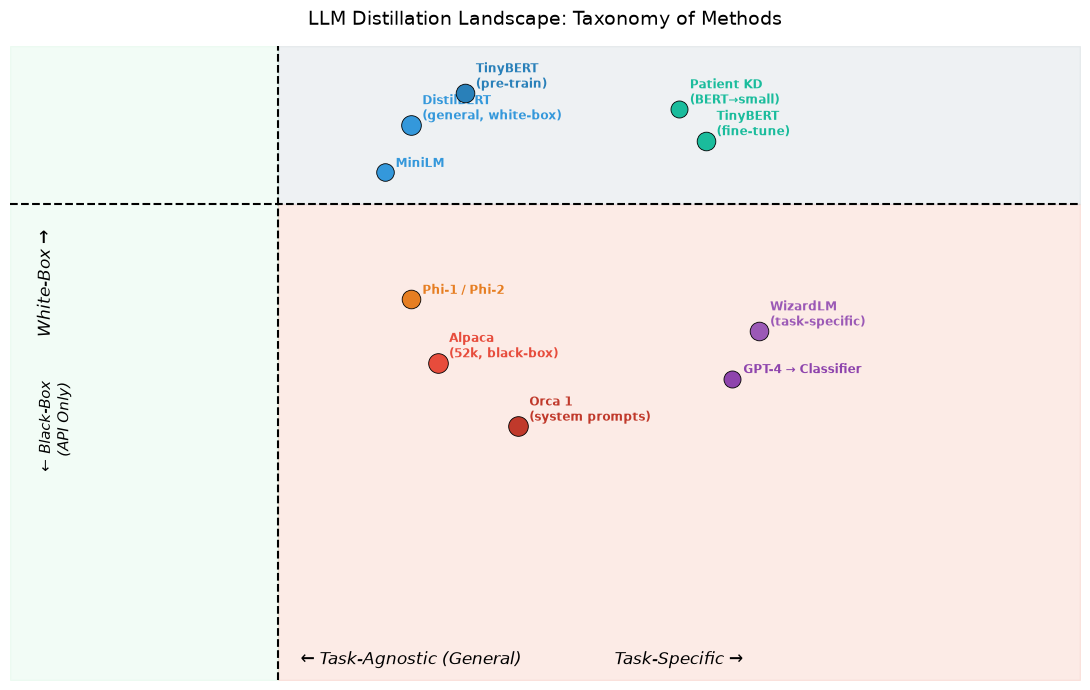

In [2]:
# ── Visualise the LLM Distillation Landscape ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)

# Quadrant backgrounds
ax.fill_between([0, 1.5], [1, 1], [1.5, 1.5], alpha=0.08, color='#3498db')
ax.fill_between([0, 1.5], [-0.5, -0.5], [1, 1], alpha=0.08, color='#e74c3c')
ax.fill_between([-0.5, 0], [-0.5, -0.5], [1.5, 1.5], alpha=0.06, color='#2ecc71')
ax.fill_between([0, 1.5], [-0.5, -0.5], [1.5, 1.5], alpha=0.04, color='#e67e22')

# Grid lines for axes
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.axhline(1, color='black', linewidth=1.5, linestyle='--')

# Models plotted as scatter points
models_plot = [
    # (x=task_scope, y=access, name, colour)
    (0.25, 1.25, 'DistilBERT\n(general, white-box)', '#3498db', 200),
    (0.20, 1.10, 'MiniLM', '#3498db', 160),
    (0.35, 1.35, 'TinyBERT\n(pre-train)', '#2980b9', 180),
    (0.80, 1.20, 'TinyBERT\n(fine-tune)', '#1abc9c', 180),
    (0.75, 1.30, 'Patient KD\n(BERT→small)', '#1abc9c', 150),
    (0.30, 0.50, 'Alpaca\n(52k, black-box)', '#e74c3c', 200),
    (0.45, 0.30, 'Orca 1\n(system prompts)', '#c0392b', 200),
    (0.25, 0.70, 'Phi-1 / Phi-2', '#e67e22', 180),
    (0.90, 0.60, 'WizardLM\n(task-specific)', '#9b59b6', 180),
    (0.85, 0.45, 'GPT-4 → Classifier', '#8e44ad', 150),
]

for x, y, name, color, size in models_plot:
    ax.scatter(x, y, s=size, c=color, zorder=5, edgecolors='black', linewidths=0.6)
    ax.annotate(name, (x, y), xytext=(8, 4), textcoords='offset points',
                fontsize=8.5, fontweight='bold', color=color)

# Axis labels
ax.text(0.75, -0.45, 'Task-Specific →', fontsize=12, ha='center', style='italic')
ax.text(-0.45, 0.75, 'White-Box →', fontsize=12, va='center', style='italic',
        rotation=90)
ax.text(0.25, -0.45, '← Task-Agnostic (General)', fontsize=12, ha='center', style='italic')
ax.text(-0.45, 0.3, '← Black-Box\n   (API Only)', fontsize=11, va='center', style='italic',
        rotation=90)

ax.set_title('LLM Distillation Landscape: Taxonomy of Methods', fontsize=14, pad=15)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.show()

---
## 3. Distillation Loss Functions for LLMs

LLM distillation combines multiple loss terms. Here we implement each from scratch.

### 3.1 Token-Level KL Divergence Loss (Logit Distillation)

The core distillation signal. At each token position, we minimise the KL divergence between the teacher's softened distribution and the student's distribution:

$$\mathcal{L}_{\text{KD}} = T^2 \cdot \text{KL}\left(\sigma\!\left(\frac{z_T}{T}\right) \;\|\; \sigma\!\left(\frac{z_S}{T}\right)\right)$$

Where $z_T$ and $z_S$ are the teacher and student logits, and $T$ is the temperature.

### 3.2 Hard Label Loss (Standard Cross-Entropy)

Standard next-token prediction loss on ground-truth labels. Keeps the student grounded in real data:

$$\mathcal{L}_{\text{CE}} = -\sum_{t} \log p_S(y_t \mid x_{<t})$$

### 3.3 Hidden State Distillation (Feature Matching)

Matches intermediate layer representations. Requires a projection layer when teacher and student have different hidden dimensions:

$$\mathcal{L}_{\text{hidn}} = \text{MSE}\left(W \cdot H_S^{(m)},\; H_T^{(n)}\right)$$

### 3.4 Attention Transfer Loss

Forces the student's attention patterns to match the teacher's, so the student learns what to "look at" in the input:

$$\mathcal{L}_{\text{attn}} = \text{MSE}\left(A_S^{(m)},\; A_T^{(n)}\right)$$

### 3.5 Combined Distillation Loss

$$\mathcal{L}_{\text{total}} = \alpha\,\mathcal{L}_{\text{KD}} + \beta\,\mathcal{L}_{\text{CE}} + \gamma\,\mathcal{L}_{\text{hidn}} + \delta\,\mathcal{L}_{\text{attn}}$$

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
#  LLM Distillation Loss Functions
# ════════════════════════════════════════════════════════════════════════════════

def kl_divergence_loss(
    student_logits: torch.Tensor,
    teacher_logits: torch.Tensor,
    temperature: float = 2.0,
    padding_mask: torch.Tensor = None,
) -> torch.Tensor:
    """
    Token-level KL Divergence loss between teacher and student distributions.

    Args:
        student_logits: Student raw logits  (B, SeqLen, VocabSize)
        teacher_logits: Teacher raw logits  (B, SeqLen, VocabSize)
        temperature:    Softening temperature T (higher → softer distributions)
        padding_mask:   Boolean mask (B, SeqLen); True where tokens are real

    Returns:
        Scalar KL loss, scaled by T² to restore gradient magnitudes.
    """
    # Temperature-scale and convert to log-probabilities for the student
    s_log_probs = F.log_softmax(student_logits / temperature, dim=-1)  # (B, L, V)

    # Temperature-scale and convert to probabilities for the teacher
    t_probs     = F.softmax(teacher_logits / temperature, dim=-1)       # (B, L, V)

    # KL(teacher || student) computed token-by-token
    # kl_div expects (input=log_probs, target=probs)
    kl_per_token = F.kl_div(
        s_log_probs,
        t_probs,
        reduction='none',
    ).sum(dim=-1)    # Sum over vocab dim → (B, SeqLen)

    if padding_mask is not None:
        # Mask out padding positions before averaging
        kl_per_token = kl_per_token * padding_mask.float()
        loss = kl_per_token.sum() / padding_mask.float().sum().clamp(min=1)
    else:
        loss = kl_per_token.mean()

    # Scale by T² to compensate for the reduced gradient magnitudes at high T
    return loss * (temperature ** 2)


def hidden_state_loss(
    student_hidden: torch.Tensor,
    teacher_hidden: torch.Tensor,
    projection: nn.Linear = None,
) -> torch.Tensor:
    """
    MSE loss between student and teacher hidden states.
    A linear projection is applied if dimensions differ.

    Args:
        student_hidden: (B, SeqLen, student_hidden_dim)
        teacher_hidden: (B, SeqLen, teacher_hidden_dim)
        projection:     Optional Linear(student_dim → teacher_dim)

    Returns:
        Scalar MSE loss.
    """
    if projection is not None:
        # Project student hidden states to teacher's dimension before comparing
        student_hidden = projection(student_hidden)

    return F.mse_loss(student_hidden, teacher_hidden.detach())  # Detach teacher!


def attention_transfer_loss(
    student_attn: torch.Tensor,
    teacher_attn: torch.Tensor,
) -> torch.Tensor:
    """
    MSE loss between student and teacher attention weight matrices.
    Forces student to learn similar attention patterns to the teacher.

    Args:
        student_attn: (B, num_heads, SeqLen, SeqLen) attention weights
        teacher_attn: (B, num_heads, SeqLen, SeqLen) attention weights

    Returns:
        Scalar MSE loss over all heads and positions.
    """
    # If head counts differ, average across heads first
    if student_attn.shape[1] != teacher_attn.shape[1]:
        student_attn = student_attn.mean(dim=1, keepdim=True)   # Average student heads
        teacher_attn = teacher_attn.mean(dim=1, keepdim=True)   # Average teacher heads

    return F.mse_loss(student_attn, teacher_attn.detach())


class LLMDistillationLoss(nn.Module):
    """
    Combined distillation loss for LLMs.

    L_total = alpha * L_KD + beta * L_CE + gamma * L_hidden + delta * L_attn

    Args:
        alpha:       Weight for soft (KL divergence) loss.
        beta:        Weight for hard label (Cross-Entropy) loss.
        gamma:       Weight for hidden state MSE loss (set 0 to disable).
        delta:       Weight for attention transfer loss (set 0 to disable).
        temperature: Softening temperature for KL loss.
    """
    def __init__(
        self,
        alpha: float = 0.7,
        beta: float = 0.3,
        gamma: float = 0.0,
        delta: float = 0.0,
        temperature: float = 2.0,
    ):
        super().__init__()
        self.alpha       = alpha
        self.beta        = beta
        self.gamma       = gamma
        self.delta       = delta
        self.temperature = temperature
        self.ce_loss     = nn.CrossEntropyLoss(ignore_index=-100)  # -100 masks padding

    def forward(
        self,
        student_logits:    torch.Tensor,
        teacher_logits:    torch.Tensor,
        labels:            torch.Tensor,
        student_hidden:    torch.Tensor = None,
        teacher_hidden:    torch.Tensor = None,
        student_attn:      torch.Tensor = None,
        teacher_attn:      torch.Tensor = None,
        hidden_projection: nn.Linear    = None,
        padding_mask:      torch.Tensor = None,
    ):
        loss_components = {}

        # ── Soft (KL) Loss ─────────────────────────────────────────────────────
        loss_kd = kl_divergence_loss(
            student_logits, teacher_logits,
            temperature=self.temperature,
            padding_mask=padding_mask
        )
        loss_components['kd'] = loss_kd

        # ── Hard (CE) Loss ─────────────────────────────────────────────────────
        # Reshape logits from (B, L, V) to (B*L, V) for CrossEntropyLoss
        B, L, V = student_logits.shape
        loss_ce = self.ce_loss(
            student_logits.view(B * L, V),
            labels.view(B * L)
        )
        loss_components['ce'] = loss_ce

        # ── Hidden State Loss ──────────────────────────────────────────────────
        loss_hidn = torch.tensor(0.0, device=student_logits.device)
        if self.gamma > 0 and student_hidden is not None and teacher_hidden is not None:
            loss_hidn = hidden_state_loss(student_hidden, teacher_hidden, hidden_projection)
            loss_components['hidden'] = loss_hidn

        # ── Attention Transfer Loss ────────────────────────────────────────────
        loss_attn = torch.tensor(0.0, device=student_logits.device)
        if self.delta > 0 and student_attn is not None and teacher_attn is not None:
            loss_attn = attention_transfer_loss(student_attn, teacher_attn)
            loss_components['attn'] = loss_attn

        # ── Combined Loss ──────────────────────────────────────────────────────
        total_loss = (
            self.alpha * loss_kd
            + self.beta  * loss_ce
            + self.gamma * loss_hidn
            + self.delta * loss_attn
        )
        loss_components['total'] = total_loss

        return total_loss, loss_components


print("Distillation loss functions defined ✅")
print()
print("Components:")
print("  L_KD     — Token-level KL divergence (soft targets, temperature-scaled)")
print("  L_CE     — Standard cross-entropy on ground-truth labels")
print("  L_hidden — Hidden state MSE (with optional projection)")
print("  L_attn   — Attention map MSE (attention transfer)")

Distillation loss functions defined ✅

Components:
  L_KD     — Token-level KL divergence (soft targets, temperature-scaled)
  L_CE     — Standard cross-entropy on ground-truth labels
  L_hidden — Hidden state MSE (with optional projection)
  L_attn   — Attention map MSE (attention transfer)


In [4]:
# ── Demonstrate Loss Functions with Random Tensors ─────────────────────────────

# Simulated batch: 2 samples, sequence length 10, vocabulary size 100
B, L, V = 2, 10, 100

torch.manual_seed(0)
teacher_logits_demo = torch.randn(B, L, V)      # Teacher logits (frozen)
student_logits_demo = torch.randn(B, L, V)      # Student logits (trainable)
labels_demo         = torch.randint(0, V, (B, L))  # Ground-truth next tokens

# Simulated hidden states (teacher: 768-dim, student: 384-dim)
teacher_hidden_demo = torch.randn(B, L, 768)
student_hidden_demo = torch.randn(B, L, 384)

# Projection to align student (384) → teacher (768) dimension
proj = nn.Linear(384, 768, bias=False)

# Simulated attention weights (4 heads for student, 12 for teacher)
student_attn_demo = torch.softmax(torch.randn(B, 4,  L, L), dim=-1)
teacher_attn_demo = torch.softmax(torch.randn(B, 12, L, L), dim=-1)

# Instantiate the combined loss
distill_loss_fn = LLMDistillationLoss(
    alpha=0.7,          # 70% weight on soft (KL) loss
    beta=0.3,           # 30% weight on hard (CE) loss
    gamma=0.1,          # Enable hidden state matching
    delta=0.05,         # Enable attention transfer
    temperature=3.0,    # Softer distributions for more inter-token signal
)

total, components = distill_loss_fn(
    student_logits=student_logits_demo,
    teacher_logits=teacher_logits_demo,
    labels=labels_demo,
    student_hidden=student_hidden_demo,
    teacher_hidden=teacher_hidden_demo,
    student_attn=student_attn_demo,
    teacher_attn=teacher_attn_demo,
    hidden_projection=proj,
)

print("=" * 45)
print("  LLMDistillationLoss — Demo Output")
print("=" * 45)
for name, val in components.items():
    print(f"  L_{name:<8}: {val.item():.4f}")
print("-" * 45)
print(f"  L_total  : {total.item():.4f}")

  LLMDistillationLoss — Demo Output
  L_kd      : 0.9500
  L_ce      : 5.3255
  L_hidden  : 1.3613
  L_attn    : 0.0031
  L_total   : 2.3989
---------------------------------------------
  L_total  : 2.3989


### 3.1 Visualising the Effect of Temperature on Soft Targets

Temperature controls how much information the teacher "leaks" about its uncertainty. At $T=1$ (no softening), the distribution is peaked. At high $T$, inter-class relationships become visible.

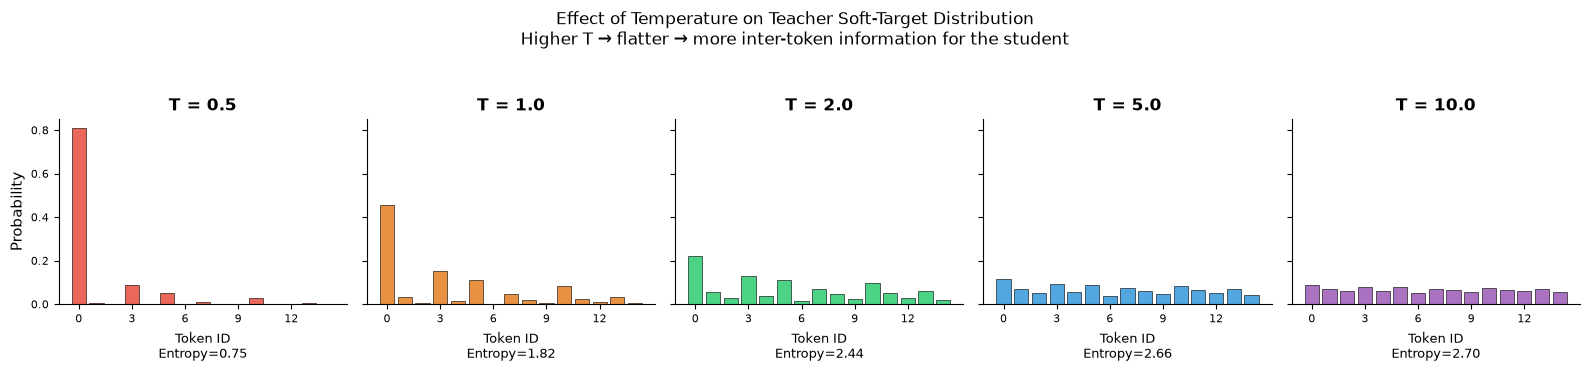

In [5]:
# ── Visualise Temperature Effect on Token Distributions ───────────────────────
np.random.seed(7)
# Simulate teacher logits for 15 vocabulary tokens
vocab_size  = 15
mock_logits = torch.tensor(
    [3.2, 0.5, -1.0, 2.1, -0.3, 1.8, -2.5, 0.9, 0.1, -1.2, 1.5, 0.3, -0.8, 0.6, -1.7],
    dtype=torch.float32
)

temperatures = [0.5, 1.0, 2.0, 5.0, 10.0]
colors_temp  = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

fig, axes = plt.subplots(1, len(temperatures), figsize=(16, 3.5), sharey=True)

for ax, T, color in zip(axes, temperatures, colors_temp):
    probs = torch.softmax(mock_logits / T, dim=0).numpy()
    ax.bar(range(vocab_size), probs, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_title(f'T = {T}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Token ID', fontsize=9)
    ax.set_xticks(range(0, vocab_size, 3))
    ax.tick_params(axis='both', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    entropy = -np.sum(probs * np.log(probs + 1e-10))
    ax.set_xlabel(f'Token ID\nEntropy={entropy:.2f}', fontsize=9)

axes[0].set_ylabel('Probability', fontsize=11)
fig.suptitle(
    'Effect of Temperature on Teacher Soft-Target Distribution\n'
    'Higher T → flatter → more inter-token information for the student',
    fontsize=12, y=1.05
)
plt.tight_layout()
plt.show()

---
## 4. Sequence-Level Knowledge Distillation (Causal LM)

Here we implement a complete **token-level distillation training loop** for a causal language model, where:
- **Teacher:** `GPT2` (medium, 345M params)
- **Student:** `distilgpt2` (82M params — the real Hugging Face distilled model)
- **Data:** WikiText-2 (standard language modelling benchmark)

### Architecture Mapping (GPT2 → DistilGPT2)

```
GPT2 (Teacher)          DistilGPT2 (Student)
─────────────────────   ─────────────────────
12 transformer layers   6 transformer layers    (every other layer kept)
12 attention heads      12 attention heads      (same per-layer capacity)
768 hidden dim          768 hidden dim          (same embedding size)
~117M parameters        ~82M parameters         (~30% smaller)
```

> **Note:** In practice, DistilGPT2 was pre-trained from scratch using distillation loss on large corpora. The loop below shows the **training logic** using small batches for demonstration.

In [6]:
# ── Load Teacher and Student Models ───────────────────────────────────────────
TEACHER_MODEL_ID = "gpt2"            # 117M params — the original GPT-2 (small)
STUDENT_MODEL_ID = "distilgpt2"      # 82M params  — the distilled version

print(f"Loading teacher: {TEACHER_MODEL_ID}...")
teacher_tokenizer = GPT2Tokenizer.from_pretrained(TEACHER_MODEL_ID)
teacher_model     = GPT2LMHeadModel.from_pretrained(TEACHER_MODEL_ID)
teacher_model     = teacher_model.to(DEVICE)

print(f"Loading student: {STUDENT_MODEL_ID}...")
student_tokenizer = GPT2Tokenizer.from_pretrained(STUDENT_MODEL_ID)
student_model     = GPT2LMHeadModel.from_pretrained(STUDENT_MODEL_ID)
student_model     = student_model.to(DEVICE)

# GPT2 tokenizer doesn't have a pad token by default — set it to eos
teacher_tokenizer.pad_token = teacher_tokenizer.eos_token
student_tokenizer.pad_token = student_tokenizer.eos_token

# Freeze the teacher — it provides fixed supervision
for param in teacher_model.parameters():
    param.requires_grad = False
teacher_model.eval()

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters()) / 1e6

print()
print(f"Teacher ({TEACHER_MODEL_ID}) parameters : {count_params(teacher_model):.1f} M")
print(f"Student ({STUDENT_MODEL_ID}) parameters : {count_params(student_model):.1f} M")
print(f"Compression ratio                       : {count_params(teacher_model) / count_params(student_model):.2f}×")

Loading teacher: gpt2...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12698.31it/s]


Loading student: distilgpt2...


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 12464.99it/s]



Teacher (gpt2) parameters : 124.4 M
Student (distilgpt2) parameters : 81.9 M
Compression ratio                       : 1.52×


In [7]:
# ── Compare Architectures Layer by Layer ──────────────────────────────────────
teacher_config = teacher_model.config
student_config = student_model.config

print("=" * 55)
print(f"{'Property':<25} {'Teacher (GPT2)':>14} {'Student (DistilGPT2)':>20}")
print("-" * 55)
props = [
    ('Layers (n_layer)',    teacher_config.n_layer,    student_config.n_layer),
    ('Attention heads',     teacher_config.n_head,     student_config.n_head),
    ('Hidden dim (n_embd)', teacher_config.n_embd,     student_config.n_embd),
    ('Context length',      teacher_config.n_positions, student_config.n_positions),
    ('Vocab size',          teacher_config.vocab_size,  student_config.vocab_size),
    ('Parameters (M)',      f"{count_params(teacher_model):.1f}",
                            f"{count_params(student_model):.1f}"),
]
for prop, t_val, s_val in props:
    print(f"{prop:<25} {str(t_val):>14} {str(s_val):>20}")
print("=" * 55)

Property                  Teacher (GPT2) Student (DistilGPT2)
-------------------------------------------------------
Layers (n_layer)                      12                    6
Attention heads                       12                   12
Hidden dim (n_embd)                  768                  768
Context length                      1024                 1024
Vocab size                         50257                50257
Parameters (M)                     124.4                 81.9


In [8]:
# ── Load WikiText-2 Dataset ────────────────────────────────────────────────────
print("Loading WikiText-2 dataset...")
raw_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

# Use a small subset for the demo (full training would use the entire dataset)
DEMO_SUBSET_SIZE = 500    # Increase for real training
raw_dataset = raw_dataset.select(range(DEMO_SUBSET_SIZE))

print(f"Dataset size (demo subset): {len(raw_dataset)} examples")
print(f"Sample text: {raw_dataset[0]['text'][:150]!r}")

Loading WikiText-2 dataset...


HfUriError: Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee71d232d685c3/.huggingface.yaml'. Repository id must be 'namespace/name', got 'wikitext'.

In [ ]:
# ── Tokenise and Create DataLoader ────────────────────────────────────────────
BLOCK_SIZE = 64    # Max sequence length per sample (small for demo speed)

def tokenize_function(examples):
    """Tokenise raw text and truncate/pad to BLOCK_SIZE."""
    return student_tokenizer(
        examples["text"],
        truncation=True,
        max_length=BLOCK_SIZE,
        padding="max_length",
        return_tensors=None,   # Return as lists (datasets will convert)
    )

# Tokenise and set format for PyTorch
tokenized_dataset = raw_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

# Filter out empty sequences
tokenized_dataset = tokenized_dataset.filter(
    lambda x: x["input_ids"].sum() > 0  # Remove rows that are all padding
)

# Create DataLoader
from torch.utils.data import DataLoader

train_loader = DataLoader(
    tokenized_dataset,
    batch_size=8,
    shuffle=True,
    drop_last=True,
)

print(f"Total batches in demo loader: {len(train_loader)}")
print(f"Sequence length             : {BLOCK_SIZE} tokens")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
#  LLM Distillation Training Loop
# ════════════════════════════════════════════════════════════════════════════════

# Hyperparameters
LEARNING_RATE    = 5e-5
DISTIL_TEMP      = 3.0       # Temperature: higher → softer teacher distributions
ALPHA            = 0.7       # KL (soft) loss weight
BETA             = 0.3       # CE (hard) loss weight
NUM_DEMO_BATCHES = 20        # Run this many batches for the demo (not full epoch)

# Optimiser — AdamW with weight decay (standard for LLM fine-tuning)
optimizer = optim.AdamW(student_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler: linear warmup then decay
total_steps = NUM_DEMO_BATCHES
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, total_steps // 10),   # 10% warmup
    num_training_steps=total_steps,
)

# Instantiate combined distillation loss (logit KD + hard CE only for this demo)
distil_criterion = LLMDistillationLoss(
    alpha=ALPHA,
    beta=BETA,
    gamma=0.0,   # Disable hidden-state loss for this demo (needs layer mapping)
    delta=0.0,   # Disable attention loss for this demo
    temperature=DISTIL_TEMP,
)

print("Starting distillation training loop (demo)...")
print(f"  Temperature : {DISTIL_TEMP}")
print(f"  Alpha (KL)  : {ALPHA}")
print(f"  Beta  (CE)  : {BETA}")
print(f"  LR          : {LEARNING_RATE}")
print()

loss_history = []
kd_history   = []
ce_history   = []

student_model.train()

for batch_idx, batch in enumerate(train_loader):
    if batch_idx >= NUM_DEMO_BATCHES:
        break

    input_ids      = batch["input_ids"].to(DEVICE)        # (B, L)
    attention_mask = batch["attention_mask"].to(DEVICE)   # (B, L)

    # Labels: for causal LM, next-token prediction (shift input_ids by 1)
    # Positions where attention_mask == 0 are padded — set labels to -100 to ignore
    labels = input_ids.clone()
    labels[attention_mask == 0] = -100   # CrossEntropyLoss ignores index -100

    # ── Teacher forward pass (no gradient) ────────────────────────────────────
    with torch.no_grad():
        teacher_outputs = teacher_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        teacher_logits = teacher_outputs.logits    # (B, L, VocabSize)

    # ── Student forward pass ──────────────────────────────────────────────────
    student_outputs = student_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )
    student_logits = student_outputs.logits        # (B, L, VocabSize)

    # ── Compute combined distillation loss ────────────────────────────────────
    total_loss, components = distil_criterion(
        student_logits=student_logits,
        teacher_logits=teacher_logits,
        labels=labels,
        padding_mask=(attention_mask == 1),   # True for real tokens
    )

    # ── Backpropagation (only student is updated) ──────────────────────────────
    optimizer.zero_grad()
    total_loss.backward()

    # Gradient clipping prevents exploding gradients during LLM training
    torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    # Track losses
    loss_history.append(total_loss.item())
    kd_history.append(components['kd'].item())
    ce_history.append(components['ce'].item())

    if (batch_idx + 1) % 5 == 0 or batch_idx == 0:
        lr_now = scheduler.get_last_lr()[0]
        print(
            f"  Batch {batch_idx + 1:>3}/{NUM_DEMO_BATCHES} | "
            f"Total: {total_loss.item():.4f} | "
            f"KD: {components['kd'].item():.4f} | "
            f"CE: {components['ce'].item():.4f} | "
            f"LR: {lr_now:.2e}"
        )

print("\nDemo training complete ✅")

In [ ]:
# ── Plot Training Loss Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

steps = range(1, len(loss_history) + 1)

# Panel 1: All loss components
axes[0].plot(steps, loss_history, 'o-', label='Total Loss', color='#2c3e50', linewidth=2)
axes[0].plot(steps, kd_history,   's-', label='KD Loss (soft)',   color='#3498db', linewidth=1.5, alpha=0.8)
axes[0].plot(steps, ce_history,   '^-', label='CE Loss (hard)',   color='#e74c3c', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Training Batch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Distillation Loss Components During Training', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2: KD vs CE proportion
axes[1].fill_between(steps,
    [ALPHA * k for k in kd_history],
    label=f'α × KD (α={ALPHA})', color='#3498db', alpha=0.6
)
axes[1].fill_between(steps,
    [BETA * c for c in ce_history],
    label=f'β × CE (β={BETA})', color='#e74c3c', alpha=0.6
)
axes[1].set_xlabel('Training Batch', fontsize=11)
axes[1].set_ylabel('Weighted Loss Contribution', fontsize=11)
axes[1].set_title('Weighted Contribution of Each Loss Term', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 5. Feature-Based Distillation (TinyBERT-Style)

**TinyBERT** (Jiao et al., 2020) is one of the most influential BERT distillation methods. It goes beyond logit matching and transfers knowledge from **every internal layer** of BERT, using a **layer mapping** strategy.

### TinyBERT Distillation Stages

```
Stage 1: General Distillation (on unlabelled text corpus)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Transfer: Embedding layer + all transformer layers
  Signals:  Hidden state MSE + Attention map MSE
  Result:   "TinyBERT_General" — a general-purpose small BERT

Stage 2: Task-Specific Distillation (on labelled fine-tune data)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Transfer: Prediction layer logits (soft targets)
  Signals:  KL Divergence on task logits
  Result:   "TinyBERT_Task" — task-optimised student
```

### Layer Mapping Strategy

The teacher has $N$ layers, the student has $M$ layers ($M < N$). We define a mapping $g(m)$ from student layer $m$ to teacher layer:

$$g(m) = m \cdot \frac{N}{M}  \quad \text{(uniform mapping)}$$

For example, mapping a 6-layer student to a 12-layer teacher: `{0→0, 1→2, 2→4, 3→6, 4→8, 5→10}`.

In [ ]:
# ── Layer Mapping for Feature-Based Distillation ───────────────────────────────

def build_layer_mapping(num_teacher_layers: int, num_student_layers: int) -> dict:
    """
    Build a uniform student-to-teacher layer mapping.
    Student layer m maps to teacher layer g(m) = m * (N/M).

    Args:
        num_teacher_layers: Number of transformer layers in the teacher.
        num_student_layers: Number of transformer layers in the student.

    Returns:
        Dict mapping {student_layer_idx: teacher_layer_idx}
    """
    ratio   = num_teacher_layers / num_student_layers
    mapping = {}
    for s_layer in range(num_student_layers):
        t_layer = int(round(s_layer * ratio))
        t_layer = min(t_layer, num_teacher_layers - 1)  # Clamp to valid range
        mapping[s_layer] = t_layer
    return mapping


# Example: 12-layer BERT → 6-layer student (like DistilBERT)
layer_map_12_to_6 = build_layer_mapping(12, 6)
layer_map_12_to_4 = build_layer_mapping(12, 4)

print("Layer Mapping Examples:")
print()
print("BERT (12L) → 6-layer student:")
for s, t in layer_map_12_to_6.items():
    print(f"  Student layer {s} ← Teacher layer {t}")

print()
print("BERT (12L) → 4-layer student:")
for s, t in layer_map_12_to_4.items():
    print(f"  Student layer {s} ← Teacher layer {t}")

In [ ]:
# ── Visualise Feature-Based Distillation Architecture ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis('off')

# Teacher layers (left column)
teacher_x = 2
teacher_layers = 12
for i in range(teacher_layers):
    y = i + 0.5
    color = '#3498db' if i in layer_map_12_to_6.values() else '#d5e8f7'
    rect = plt.Rectangle((teacher_x - 0.8, y), 1.6, 0.8,
                           facecolor=color, edgecolor='#2c3e50', linewidth=0.8)
    ax.add_patch(rect)
    ax.text(teacher_x, y + 0.4, f'L{i}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='white' if color != '#d5e8f7' else '#2c3e50')

# Student layers (right column)
student_x = 8
student_layers = 6
student_y_positions = {}
for s, t in layer_map_12_to_6.items():
    y = t + 0.5
    student_y_positions[s] = y + 0.4
    rect = plt.Rectangle((student_x - 0.8, y), 1.6, 0.8,
                           facecolor='#e74c3c', edgecolor='#c0392b', linewidth=0.8)
    ax.add_patch(rect)
    ax.text(student_x, y + 0.4, f'L{s}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')

# Arrows connecting corresponding layers
for s, t in layer_map_12_to_6.items():
    t_y = t + 0.9
    s_y = t + 0.9
    ax.annotate('',
        xy=(student_x - 0.8, s_y), xytext=(teacher_x + 0.8, t_y),
        arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.8)
    )

# Labels
ax.text(teacher_x, 12.7, 'TEACHER (BERT, 12L)', ha='center', fontsize=12,
        fontweight='bold', color='#3498db')
ax.text(student_x, 12.7, 'STUDENT (6L)', ha='center', fontsize=12,
        fontweight='bold', color='#e74c3c')
ax.text(5, 12.7, '→ MSE (Hidden) →\n→ MSE (Attention) →', ha='center',
        fontsize=9, color='#2ecc71')

ax.text(teacher_x, 0.1, 'Blue = mapped layers', ha='center', fontsize=8,
        color='#3498db')

ax.set_title('TinyBERT-Style Layer Mapping: Teacher → Student\n'
             'Green arrows = hidden-state + attention MSE loss signals',
             fontsize=12, pad=10)

plt.tight_layout()
plt.show()

---
## 6. Black-Box Distillation — The Alpaca / Orca Paradigm

When you don't have access to the teacher's internal weights (e.g., you're using GPT-4 via API), you can still distil knowledge through **model-generated data**.

### The Pipeline

```
Step 1: Seed Data
  Hand-craft ~100–500 diverse (instruction, response) examples.

Step 2: Teacher Data Generation
  Prompt the teacher LLM (e.g., GPT-4) with:
  • The seed examples (few-shot)
  • Instructions to generate N more examples
  → Teacher generates 50k–1M synthetic training pairs

Step 3: Student Fine-Tuning
  Fine-tune a smaller open-source model (e.g., LLaMA-7B)
  on the teacher-generated data using standard SFT loss.

Step 4: (Optional) DPO / RLHF
  Further align the student with preference data.
```

### Famous Examples

| Model | Teacher | Student | Data Size | Key Innovation |
|---|---|---|---|---|
| **Alpaca** | `text-davinci-003` | LLaMA-7B | 52k instructions | Self-instruct pipeline |
| **Vicuna** | ChatGPT | LLaMA-13B | 70k conversations | ShareGPT data |
| **Orca 1** | GPT-4 | LLaMA-13B | 5M samples | System prompts + chain-of-thought |
| **Orca 2** | GPT-4 | Mistral-7B | Curated | Cautious reasoning strategies |
| **Phi-1** | GPT-4 | 1.3B custom | ~7B tokens | "Textbook is all you need" — quality over quantity |
| **Phi-2** | GPT-4 | 2.7B custom | 250B tokens | Synthetic + web data |
| **WizardLM** | ChatGPT | LLaMA-7B | 70k evolved | Evol-Instruct: progressively harder instructions |

In [ ]:
# ── Simulate the Alpaca-style Self-Instruct Data Generation Pipeline ───────────
# (In production, this calls GPT-4 API; here we simulate the prompt structure)

SEED_EXAMPLES = [
    {
        "instruction": "Write a haiku about the moon.",
        "input": "",
        "output": "Silver light descends / Quiet lake reflects the glow / Moon and water breathe"
    },
    {
        "instruction": "Explain gradient descent in one sentence.",
        "input": "",
        "output": "Gradient descent iteratively adjusts model parameters in the direction that most reduces the loss function."
    },
    {
        "instruction": "Translate the following to French.",
        "input": "The weather is beautiful today.",
        "output": "Le temps est magnifique aujourd'hui."
    },
]


def build_alpaca_prompt(instruction: str, input_text: str = "") -> str:
    """
    Build the Alpaca prompt format used to fine-tune LLaMA.
    This format conditions the student to follow instructions.

    Args:
        instruction: The task description.
        input_text:  Optional additional context (can be empty).

    Returns:
        Formatted prompt string.
    """
    if input_text:
        return (
            "Below is an instruction that describes a task, paired with an input "
            "that provides further context. Write a response that appropriately "
            "completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_text}\n\n"
            "### Response:\n"
        )
    else:
        return (
            "Below is an instruction that describes a task. Write a response that "
            "appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            "### Response:\n"
        )


def build_self_instruct_prompt(seed_examples: list, n_generate: int = 5) -> str:
    """
    Build the meta-prompt sent to GPT-4 (the teacher) to generate
    new instruction-response pairs from seed examples.

    Args:
        seed_examples: List of seed {instruction, input, output} dicts.
        n_generate:    Number of new examples to request.

    Returns:
        Formatted meta-prompt string.
    """
    seed_text = ""
    for i, ex in enumerate(seed_examples, start=1):
        seed_text += f"Example {i}:\n"
        seed_text += f"  Instruction: {ex['instruction']}\n"
        if ex['input']:
            seed_text += f"  Input: {ex['input']}\n"
        seed_text += f"  Output: {ex['output']}\n\n"

    return (
        f"You are a helpful assistant. Here are {len(seed_examples)} examples of "
        f"diverse instruction-following tasks:\n\n"
        f"{seed_text}"
        f"Generate {n_generate} new, diverse examples in the exact same format. "
        f"Ensure variety in task type, difficulty, and domain.\n\nNew examples:"
    )


# Print the Alpaca prompt format
print("=" * 65)
print(" Alpaca Prompt Format (used to fine-tune the student)")
print("=" * 65)
for ex in SEED_EXAMPLES[:2]:
    print(build_alpaca_prompt(ex['instruction'], ex['input']))
    print(f"[Expected output]: {ex['output']}")
    print("-" * 65)

print()
print("=" * 65)
print(" Self-Instruct Meta-Prompt (sent to GPT-4 teacher)")
print("=" * 65)
meta_prompt = build_self_instruct_prompt(SEED_EXAMPLES, n_generate=5)
print(meta_prompt[:800] + "...")

---
## 7. DistilBERT Case Study — Inspecting a Real Distilled LLM

**DistilBERT** (Sanh et al., 2019) is the canonical example of white-box, task-agnostic LLM distillation. It achieves **97% of BERT's performance** while being **40% smaller** and **60% faster**.

### DistilBERT's Distillation Recipe

| Component | Detail |
|---|---|
| Teacher | `bert-base-uncased` (12 layers) |
| Student | 6-layer transformer (half the depth) |
| Weight Initialisation | Student layers initialised from **every other teacher layer** |
| Training Data | English Wikipedia + BookCorpus (same as BERT) |
| Loss | `L = α·L_MLM + β·L_KD + γ·L_cos` (MLM + soft KL + cosine embedding loss) |
| Cosine loss | Aligns the directions of teacher and student hidden states |

In [ ]:
# ── Load BERT (Teacher) and DistilBERT (Student) ───────────────────────────────
print("Loading BERT (teacher)...")
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model     = BertModel.from_pretrained("bert-base-uncased")

print("Loading DistilBERT (student)...")
distilbert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
distilbert_model     = DistilBertModel.from_pretrained("distilbert-base-uncased")

bert_model.eval()
distilbert_model.eval()


def model_summary(name, model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb      = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    return {
        'Model':      name,
        'Total Params': f"{total_params / 1e6:.1f} M",
        'Size (MB)':  f"{size_mb:.1f} MB",
    }

bert_info       = model_summary("BERT",       bert_model)
distilbert_info = model_summary("DistilBERT", distilbert_model)

print()
print("=" * 50)
print(f"{'Property':<20} {'BERT':>12} {'DistilBERT':>14}")
print("-" * 50)
properties = [
    ('Layers',          bert_model.config.num_hidden_layers,
                        distilbert_model.config.n_layers),
    ('Attention heads', bert_model.config.num_attention_heads,
                        distilbert_model.config.n_heads),
    ('Hidden dim',      bert_model.config.hidden_size,
                        distilbert_model.config.dim),
    ('Parameters',      bert_info['Total Params'],
                        distilbert_info['Total Params']),
    ('Size (MB)',       bert_info['Size (MB)'],
                        distilbert_info['Size (MB)']),
]
for prop, b_val, d_val in properties:
    print(f"{prop:<20} {str(b_val):>12} {str(d_val):>14}")
print("=" * 50)

bert_mb       = float(bert_info['Size (MB)'].replace(' MB', ''))
distilbert_mb = float(distilbert_info['Size (MB)'].replace(' MB', ''))
print(f"\nSize reduction : {(1 - distilbert_mb/bert_mb)*100:.1f}% smaller")

In [ ]:
# ── Compare Hidden Representations: BERT vs. DistilBERT ───────────────────────
TEST_SENTENCES = [
    "The quick brown fox jumps over the lazy dog.",
    "Knowledge distillation compresses large models into smaller ones.",
    "Paris is the capital of France.",
]

def get_cls_embedding(model, tokenizer, text: str, device: str = "cpu") -> np.ndarray:
    """
    Extract the [CLS] token embedding from a BERT-style model.
    The [CLS] embedding is a standard sentence-level representation.

    Args:
        model:     BERT or DistilBERT model.
        tokenizer: Corresponding tokenizer.
        text:      Input sentence.
        device:    Torch device.

    Returns:
        CLS embedding as a numpy array.
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    # outputs.last_hidden_state shape: (1, seq_len, hidden_dim)
    cls_embedding = outputs.last_hidden_state[0, 0, :].numpy()  # [CLS] token
    return cls_embedding


print("Computing CLS embeddings...")
print()

for sent in TEST_SENTENCES:
    bert_emb       = get_cls_embedding(bert_model,       bert_tokenizer,       sent)
    distilbert_emb = get_cls_embedding(distilbert_model, distilbert_tokenizer, sent)

    # Cosine similarity between BERT and DistilBERT embeddings
    cos_sim = np.dot(bert_emb, distilbert_emb) / (
        np.linalg.norm(bert_emb) * np.linalg.norm(distilbert_emb)
    )
    l2_dist = np.linalg.norm(bert_emb - distilbert_emb)

    print(f"Text    : {sent[:60]!r}")
    print(f"  BERT dim / DistilBERT dim : {bert_emb.shape[0]} / {distilbert_emb.shape[0]}")
    print(f"  Cosine Similarity         : {cos_sim:.4f}")
    print(f"  L2 Distance               : {l2_dist:.4f}")
    print()

In [ ]:
# ── Inference Speed Comparison: BERT vs. DistilBERT ───────────────────────────
import time

def benchmark_inference(
    model, tokenizer, texts: list, n_runs: int = 50, device: str = "cpu"
) -> float:
    """
    Benchmark inference speed by running n_runs forward passes.

    Args:
        model:     Model to benchmark.
        tokenizer: Tokenizer for the model.
        texts:     List of input sentences.
        n_runs:    Number of timing iterations.
        device:    Torch device.

    Returns:
        Average inference time in milliseconds.
    """
    inputs = tokenizer(
        texts, return_tensors="pt", truncation=True,
        padding=True, max_length=128
    )
    model.eval()

    # Warm-up runs (not timed) — first runs are slower due to cache misses
    with torch.no_grad():
        for _ in range(5):
            _ = model(**inputs)

    # Timed runs
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(**inputs)
    elapsed = time.perf_counter() - start

    return (elapsed / n_runs) * 1000  # Convert to ms


N_RUNS = 30
bert_time       = benchmark_inference(bert_model,       bert_tokenizer,       TEST_SENTENCES, N_RUNS)
distilbert_time = benchmark_inference(distilbert_model, distilbert_tokenizer, TEST_SENTENCES, N_RUNS)

print(f"Inference Speed (avg over {N_RUNS} runs, batch size = {len(TEST_SENTENCES)}):")
print(f"  BERT       : {bert_time:.2f} ms/batch")
print(f"  DistilBERT : {distilbert_time:.2f} ms/batch")
print(f"  Speedup    : {bert_time / distilbert_time:.2f}×")
print()

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models_cmp  = ['BERT\n(Teacher)', 'DistilBERT\n(Student)']
times_ms    = [bert_time, distilbert_time]
params_m    = [float(bert_info['Total Params'].replace(' M', '')),
               float(distilbert_info['Total Params'].replace(' M', ''))]
bar_colors  = ['#3498db', '#e74c3c']

axes[0].bar(models_cmp, times_ms, color=bar_colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Inference Latency (lower = better)', fontsize=12)
axes[0].set_ylabel('ms per batch', fontsize=11)
for bar, t in zip(axes[0].patches, times_ms):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{t:.1f} ms', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(models_cmp, params_m, color=bar_colors, edgecolor='black', linewidth=0.7)
axes[1].set_title('Model Size — Parameters', fontsize=12)
axes[1].set_ylabel('Parameters (Millions)', fontsize=11)
for bar, p in zip(axes[1].patches, params_m):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{p:.0f} M', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 8. Evaluation Metrics for LLM Distillation

Quality assessment spans three dimensions:

### 8.1 Language Modelling Quality — Perplexity

**Perplexity (PPL)** measures how well the model predicts unseen text. Lower is better.

$$\text{PPL} = \exp\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i \mid w_1, \ldots, w_{i-1})\right)$$

### 8.2 Downstream Task Performance
- GLUE / SuperGLUE benchmarks (for encoder models like BERT)
- MMLU, HellaSwag, ARC (for decoder/causal LLMs)
- Task-specific F1, Accuracy, ROUGE, BLEU

### 8.3 Compression Metrics
- **Size reduction:** `(1 - student_params / teacher_params) × 100%`
- **Speedup:** `teacher_latency / student_latency`
- **Retention:** `student_accuracy / teacher_accuracy × 100%`

In [ ]:
# ── Perplexity Computation ─────────────────────────────────────────────────────

def compute_perplexity(
    model: nn.Module,
    tokenizer,
    texts: list,
    device: str = "cpu",
    max_length: int = 128,
) -> float:
    """
    Compute perplexity of a causal language model on a list of texts.

    Perplexity = exp(average negative log-likelihood per token).

    Args:
        model:      A CausalLM model (e.g., GPT2).
        tokenizer:  Corresponding tokenizer.
        texts:      List of evaluation strings.
        device:     Torch device.
        max_length: Max tokens per example.

    Returns:
        Perplexity score (lower = better).
    """
    model.eval()
    total_log_likelihood = 0.0
    total_tokens         = 0

    with torch.no_grad():
        for text in texts:
            encoding = tokenizer(
                text, return_tensors="pt",
                truncation=True, max_length=max_length
            )
            input_ids = encoding["input_ids"].to(device)

            if input_ids.shape[1] < 2:  # Skip sequences that are too short
                continue

            outputs = model(input_ids, labels=input_ids)  # labels=input_ids → next-token CE

            # outputs.loss is already the mean NLL per token
            n_tokens = input_ids.shape[1] - 1  # Exclude the first token (no prediction)
            total_log_likelihood += outputs.loss.item() * n_tokens
            total_tokens         += n_tokens

    if total_tokens == 0:
        return float('inf')

    avg_nll    = total_log_likelihood / total_tokens
    perplexity = math.exp(avg_nll)          # PPL = e^(mean NLL)
    return perplexity


# Evaluate GPT2 (teacher) and DistilGPT2 (student) on a small sample
EVAL_TEXTS = [
    "The history of natural language processing generally started in the 1950s.",
    "Machine learning models can be compressed using knowledge distillation.",
    "Large language models have transformed the field of artificial intelligence.",
    "The student model learns to mimic the teacher's soft probability distributions.",
    "Neural networks consist of layers of interconnected artificial neurons.",
]

print("Computing perplexity on evaluation texts...")
teacher_ppl = compute_perplexity(teacher_model, teacher_tokenizer, EVAL_TEXTS, DEVICE)
student_ppl = compute_perplexity(student_model, student_tokenizer, EVAL_TEXTS, DEVICE)

print()
print("=" * 40)
print(f"  GPT2 (Teacher)  PPL : {teacher_ppl:.2f}")
print(f"  DistilGPT2 (Student) PPL : {student_ppl:.2f}")
print(f"  PPL gap : {student_ppl - teacher_ppl:+.2f}")
print("=" * 40)
print(f"  (Lower = better; gap shows cost of distillation)")

---
## 9. Benchmarking Real Distilled LLMs

A comparison of notable distilled/small LLMs against their teachers across key dimensions.

In [ ]:
# ── Real-World Distilled LLM Benchmark Data ────────────────────────────────────
# Data sourced from original papers and open leaderboards (approximate values)

distilled_models = [
    # (name, teacher, teacher_B, student_B, mmlu%, speedup, glue%)
    # MMLU = 5-shot, GLUE = aggregate score (for encoder models: SST-2/MNLI/QQP)
    ('DistilBERT',      'BERT-base',        0.11,  0.066, None, 1.6,  97.0),
    ('TinyBERT-6L',     'BERT-base',        0.11,  0.067, None, 2.0,  98.2),
    ('MiniLM-L6',       'BERT-large',       0.34,  0.066, None, 2.5,  99.0),
    ('DistilGPT2',      'GPT2',             0.12,  0.082, None, 2.0,  None),
    ('Alpaca-7B',       'text-davinci-003', None,  7.0,  42.1, None,  None),
    ('Vicuna-13B',      'ChatGPT',          None,  13.0, 52.1, None,  None),
    ('Orca-2-7B',       'GPT-4',            None,  7.0,  63.2, None,  None),
    ('Phi-2 (2.7B)',    'GPT-4 (synth)',    None,  2.7,  61.8, None,  None),
    ('Mistral-7B',      'Mixture (SFT)',    None,  7.0,  62.5, None,  None),
]

# ── Print Table ───────────────────────────────────────────────────────────────
print("=" * 90)
print(f"{'Model':<18} {'Teacher':<22} {'Teacher (B)':>11} {'Student (B)':>11} {'MMLU (%)':>9} {'Speedup':>8} {'GLUE (%)':>9}")
print("-" * 90)
for row in distilled_models:
    name, teacher, t_b, s_b, mmlu, speedup, glue = row
    t_b_str    = f"{t_b:.2f}" if t_b else "—"
    mmlu_str   = f"{mmlu:.1f}" if mmlu else "—"
    speedup_str= f"{speedup:.1f}×" if speedup else "—"
    glue_str   = f"{glue:.1f}" if glue else "—"
    print(f"{name:<18} {teacher:<22} {t_b_str:>11} {s_b:>11.1f} {mmlu_str:>9} {speedup_str:>8} {glue_str:>9}")
print("=" * 90)
print("Note: — = metric not applicable for this model type.")
print("      MMLU (5-shot) measures general knowledge; GLUE is for encoder models.")

In [ ]:
# ── Visualise: Parameter Count vs. MMLU Score (Decoder LLMs only) ─────────────
decoder_models = [
    ('GPT-4\n(Teacher)',    1760, 86.4, '#e74c3c', 350),
    ('GPT-3.5\n(Teacher)',  175,  70.0, '#e67e22', 250),
    ('LLaMA-2-13B\n(base)', 13,   54.8, '#95a5a6', 180),
    ('Mistral-7B',          7,    62.5, '#3498db', 180),
    ('Vicuna-13B',          13,   52.1, '#2ecc71', 180),
    ('Orca-2-7B',           7,    63.2, '#9b59b6', 200),
    ('Phi-2\n(2.7B)',       2.7,  61.8, '#1abc9c', 180),
    ('Alpaca-7B',           7,    42.1, '#f39c12', 150),
]

fig, ax = plt.subplots(figsize=(11, 6))

for name, params, mmlu, color, size in decoder_models:
    ax.scatter(params, mmlu, s=size, c=color, alpha=0.85,
               edgecolors='black', linewidths=0.7, zorder=4)
    ax.annotate(name, (params, mmlu), xytext=(6, 4),
                textcoords='offset points', fontsize=8.5, fontweight='bold', color=color)

ax.set_xscale('log')   # Log scale because teacher (GPT-4 = 1760B) dwarfs others
ax.set_xlabel('Model Parameters (Billions, log scale)', fontsize=12)
ax.set_ylabel('MMLU Score (5-shot, %)', fontsize=12)
ax.set_title(
    'LLM Distillation: Parameter Count vs. MMLU Benchmark Score\n'
    '(Distilled students aim for upper-left: high score, few params)',
    fontsize=12, pad=10
)

# Shade the "efficient distillation zone"
ax.axvspan(1, 15, alpha=0.06, color='#2ecc71', label='Efficient zone (1–15B)')
ax.axhline(y=62, color='gray', linestyle='--', linewidth=1, alpha=0.7,
           label='GPT-3.5 approximate threshold (70%)')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 10. Best Practices & Decision Guide

### Choosing the Right Distillation Strategy

```
START: What do you have access to?
│
├── Teacher weights/activations accessible?
│   ├── YES (White-Box) ──────────────────────────────────────────────────────
│   │   ├── Want a general-purpose student?  →  DistilBERT-style (all layers)
│   │   │     Loss: KL + MSE(hidden) + MSE(attn) + cosine
│   │   │     Init: Copy every other teacher layer into student
│   │   │
│   │   ├── Want task-specific distillation?  →  TinyBERT fine-tuning stage
│   │   │     Loss: KL on task logits only
│   │   │     Fast: 1–2 epochs on labelled task data
│   │   │
│   │   └── Want maximum quality at 4-bit?  →  GPTQ/AWQ + distillation loss
│   │         Quantize then distil (or simultaneously)
│   │
│   └── NO (Black-Box, API only) ────────────────────────────────────────────
│       ├── Have labelled data?  →  Fine-tune student on teacher API outputs
│       │     (Soft targets not available — use hard labels or log-probs if provided)
│       │
│       └── No labelled data?  →  Self-Instruct / Alpaca pipeline
│             1. Generate synthetic data from teacher
│             2. SFT student on teacher-generated (instruction, response) pairs
│             3. Optional: DPO on preference data
```

### Critical Hyperparameters

| Hyperparameter | Typical Range | Effect |
|---|---|---|
| Temperature (T) | 2–10 | Higher → more informative soft targets |
| Alpha (KL weight) | 0.5–0.9 | Higher → trust teacher more |
| Learning rate | 1e-5 – 5e-5 | Lower than standard for stability |
| Warmup steps | 5–10% of total | Prevents early instability |
| Layer mapping | Uniform or top-k | Uniform is robust; top-k focuses on final layers |
| Calibration data | 128–512 samples | Data quality > quantity for PTQ-style distil |

### Common Pitfalls

| Pitfall | Solution |
|---|---|
| Student doesn't improve over baseline | Check teacher is NOT frozen accidentally updated |
| KL loss dominates / CE loss ignored | Reduce alpha; ensure CE loss is non-zero |
| Hidden dim mismatch crash | Always add a projection layer when dims differ |
| Poor black-box data quality | Filter: remove degenerate outputs; use RLHF/DPO |
| Catastrophic forgetting | Use LR warmup + gradient clipping (max_norm=1.0) |

In [ ]:
# ── Final Summary: Distillation Methods Comparison ────────────────────────────
categories = ['Quality\nRetention', 'Speed\n(Throughput)', 'Memory\nSavings',
              'Ease of\nImplement.', 'Data\nEfficiency']

methods_radar = {
    'Logit-KD Only\n(White-Box)':      [0.85, 0.80, 0.75, 0.90, 0.80],
    'TinyBERT\n(Full White-Box)':      [0.97, 0.85, 0.80, 0.50, 0.70],
    'Alpaca\n(Black-Box SFT)':         [0.70, 0.85, 0.80, 0.95, 0.60],
    'Orca\n(Black-Box + CoT)':         [0.88, 0.85, 0.80, 0.75, 0.90],
    'Phi-2\n(Synthetic Data)':         [0.92, 0.95, 0.95, 0.70, 0.95],
}

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]    # Close the polygon

colors_radar = ['#3498db', '#2ecc71', '#e74c3c', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for (method, scores), color in zip(methods_radar.items(), colors_radar):
    values = scores + scores[:1]   # Close the radar polygon
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=method)
    ax.fill(angles, values, alpha=0.07, color=color)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.grid(True, alpha=0.4)

ax.set_title(
    'LLM Distillation Methods — Multi-Dimensional Comparison\n'
    '(Outer = better)',
    fontsize=13, pad=20
)
ax.legend(
    loc='upper right', bbox_to_anchor=(1.4, 1.15),
    fontsize=9, framealpha=0.9
)

plt.tight_layout()
plt.show()

---
## 📊 Summary & Key Takeaways

### What We Covered

| Section | Takeaway |
|---|---|
| **Taxonomy** | White-box vs. black-box; task-specific vs. general |
| **Loss Functions** | KL divergence, CE, hidden-state MSE, attention MSE — each captures different knowledge |
| **Sequence-Level KD** | Token-level KL loss with temperature on a causal LM (GPT2 → DistilGPT2) |
| **TinyBERT-style** | Layer mapping + intermediate supervision captures richer structural knowledge |
| **Black-Box (Alpaca/Orca)** | When you only have API access, generate synthetic data for SFT |
| **DistilBERT Case Study** | 40% smaller, 60% faster, 97% accuracy retention |
| **Benchmarks** | Phi-2 (2.7B) and Orca-2 (7B) show that small distilled models can approach GPT-3.5 |

### The Distillation Hierarchy of Signals

```
Most Signal ──────────────────────────────────────── Least Signal

  Weights  >  Hidden States  >  Attention  >  Logits  >  Generated Text
  (param copy)  (MSE)           (MSE)          (KL)      (SFT on outputs)

   White-Box ◄─────────────────────────────────────► Black-Box
```

### Further Reading

- **DistilBERT** — [arxiv.org/abs/1910.01108](https://arxiv.org/abs/1910.01108)
- **TinyBERT** — [arxiv.org/abs/1909.10351](https://arxiv.org/abs/1909.10351)
- **MiniLM** — [arxiv.org/abs/2002.10957](https://arxiv.org/abs/2002.10957)
- **Alpaca / Self-Instruct** — [arxiv.org/abs/2212.10560](https://arxiv.org/abs/2212.10560)
- **Orca 1** — [arxiv.org/abs/2306.02707](https://arxiv.org/abs/2306.02707)
- **Orca 2** — [arxiv.org/abs/2311.11045](https://arxiv.org/abs/2311.11045)
- **Phi-2** — [microsoft.com/en-us/research/blog/phi-2](https://www.microsoft.com/en-us/research/blog/phi-2-the-surprising-power-of-small-language-models/)
- **Knowledge Distillation Survey** — [arxiv.org/abs/2006.05525](https://arxiv.org/abs/2006.05525)